<a href="https://colab.research.google.com/github/hrulevskaya/ML_tasks/blob/main/task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
import tensorflow as tf
print(tf.__version__)

import tensorflow.keras as  keras
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Reshape,AveragePooling2D, SeparableConv2D,Conv2D, MaxPooling2D
from tensorflow.keras import backend as K

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import shutil

2.20.0


In [ ]:
data_dirs = {
    'yes': '/content/gdrive/MyDrive/yes',
    'no': '/content/gdrive/MyDrive/no'
}
categories = ['yes', 'no']

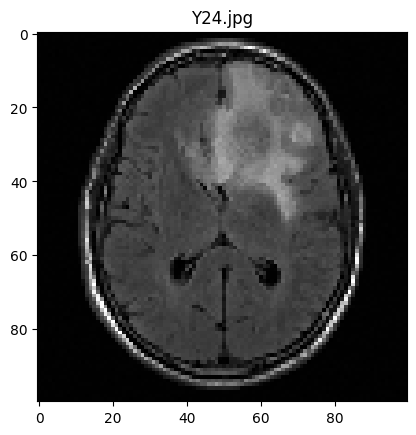

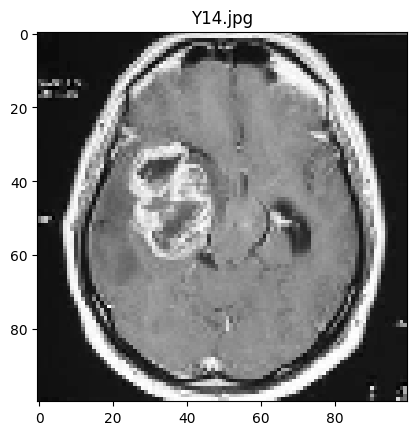

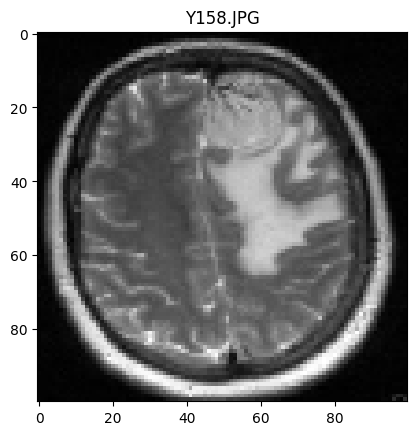

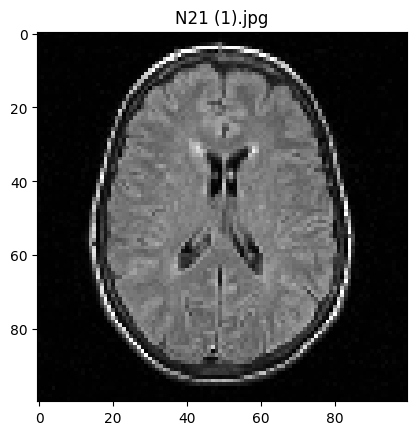

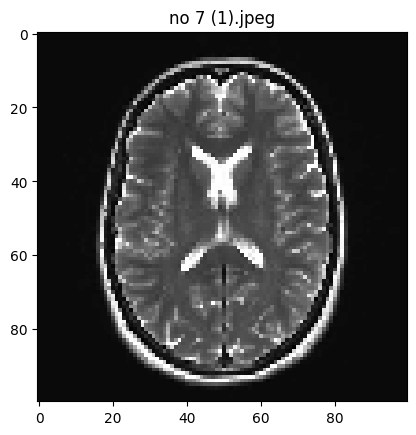

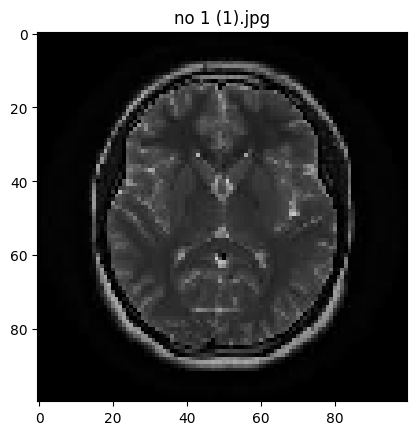

In [ ]:
fnames = []

for category in categories:
    category_dir = data_dirs[category]
    fnames.extend([os.path.join(category_dir, fname) for fname in os.listdir(category_dir)][:3])

i = 0
for img_path in fnames:
    img = image.load_img(img_path, target_size=(100, 100))
    plt.figure(i)
    plt.grid(False)
    imgplot = plt.imshow(img)
    plt.title(os.path.basename(img_path))
    i += 1

plt.show()

In [ ]:
for category in categories:
    category_dir = data_dirs[category]
    fnames.extend([os.path.join(category_dir, fname) for fname in os.listdir(category_dir)])

print(fnames)

['/content/gdrive/MyDrive/yes/Y24.jpg', '/content/gdrive/MyDrive/yes/Y14.jpg', '/content/gdrive/MyDrive/yes/Y158.JPG', '/content/gdrive/MyDrive/no/N21 (1).jpg', '/content/gdrive/MyDrive/no/no 7 (1).jpeg', '/content/gdrive/MyDrive/no/no 1 (1).jpg', '/content/gdrive/MyDrive/yes/Y24.jpg', '/content/gdrive/MyDrive/yes/Y14.jpg', '/content/gdrive/MyDrive/yes/Y158.JPG', '/content/gdrive/MyDrive/yes/Y185.jpg', '/content/gdrive/MyDrive/yes/Y114.JPG', '/content/gdrive/MyDrive/yes/Y167.JPG', '/content/gdrive/MyDrive/yes/Y12.jpg', '/content/gdrive/MyDrive/yes/Y161.JPG', '/content/gdrive/MyDrive/yes/Y11.jpg', '/content/gdrive/MyDrive/yes/Y100.JPG', '/content/gdrive/MyDrive/yes/Y192.JPG', '/content/gdrive/MyDrive/yes/Y146.JPG', '/content/gdrive/MyDrive/yes/Y109.JPG', '/content/gdrive/MyDrive/yes/Y19.JPG', '/content/gdrive/MyDrive/yes/Y101.jpg', '/content/gdrive/MyDrive/yes/Y186.jpg', '/content/gdrive/MyDrive/yes/Y1.jpg', '/content/gdrive/MyDrive/yes/Y165.JPG', '/content/gdrive/MyDrive/yes/Y147.JPG',

In [ ]:
X = []
from tensorflow.keras.applications import mobilenet,mobilenet_v2
INPUT_SHAPE = 224
net_model = mobilenet_v2
net_model_class = net_model.MobileNetV2
c = 0
model = net_model_class(weights='imagenet', input_shape=(INPUT_SHAPE, INPUT_SHAPE, 3), include_top=False, pooling='avg')
features_dict = {}

for category in categories:
    category_dir = data_dirs[category]
    category_fnames = [os.path.join(category_dir, fname) for fname in os.listdir(category_dir)][:]

    for img_path in category_fnames:
        c += 1
        img = image.load_img(img_path, target_size=(INPUT_SHAPE, INPUT_SHAPE))
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = net_model.preprocess_input(x)

        preds = model.predict(x)
        features_dict[str(os.path.basename(img_path) + "_" + str(c))] = preds
        X.append(np.array(preds))
        # print('Predicted:', preds.shape, preds)

print(c)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/

In [ ]:
X1 = []
Y = []

for key, value in features_dict.items():
    if 'Y' in key.upper() or 'yes' in key.lower():
        label = 1
    elif 'N' in key.upper() or 'no' in key.lower():
        label = 0

    X1.append(value.flatten())
    Y.append(label)

print(f"Размер X1: {len(X1)}")
print(f"Размер Y: {len(Y)}")
print(f"Распределение: {Y.count(0)} без опухоли, {Y.count(1)} с опухолью")

Размер X1: 306
Размер Y: 306
Распределение: 151 без опухоли, 155 с опухолью


In [ ]:
data_X = np.array(X1)
data_Y = np.array(Y)

In [ ]:
print("Shape of X:", data_X.shape)
print("Shape of Y:", data_Y.shape)

Shape of X: (306, 1280)
Shape of Y: (306,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn import metrics

X_train, X_test, Y_train, Y_test = train_test_split(data_X, data_Y, test_size=0.2, random_state=2)

In [ ]:
def calc_metrics_cls(true, pred):
    stats = {
        'Accuracy': round(metrics.accuracy_score(true, pred),2),
        'F1': round(metrics.f1_score(true, pred, average='macro'),2)
    }
    print(f"Accuracy: {stats['Accuracy']}\nF1: {stats['F1']}")
    return stats
cls_models_stats = {}

In [ ]:
from sklearn.ensemble import RandomForestClassifier #  Random Forest многоклассовой классификации

cls_model_rf = RandomForestClassifier()
cls_model_rf.fit(X_train, Y_train)
Y_pred_cls_rf = cls_model_rf.predict(X_test)

#cls_metrics_stats = calc_metrics_cls(Y_test, Y_pred_cls_rf)
cls_models_stats['RandomForest'] = calc_metrics_cls(Y_test, Y_pred_cls_rf)

Accuracy: 0.89
F1: 0.89


In [ ]:
from sklearn.linear_model import SGDClassifier #  метод градиентного спуска

cls_model_sgd = SGDClassifier()
cls_model_sgd.fit(X_train, Y_train)
Y_pred_cls_sgd = cls_model_sgd.predict(X_test)
cls_models_stats['SGDClassifier'] = calc_metrics_cls(Y_test, Y_pred_cls_sgd)

Accuracy: 0.95
F1: 0.95


In [ ]:
from sklearn.svm import SVC #  метод опорных векторов

cls_model_svc = SVC()
cls_model_svc.fit(X_train, Y_train)
Y_pred_cls_svc = cls_model_svc.predict(X_test)

#cls_metrics_stats = calc_metrics_cls(Y_test, Y_pred_cls_svc)
cls_models_stats['SVC'] = calc_metrics_cls(Y_test, Y_pred_cls_svc)

Accuracy: 0.92
F1: 0.92


In [ ]:
import torch

import torch.nn as nn
import torch.optim as optim

In [ ]:
class MRIClassifierHead(nn.Module):
    def __init__(self, input_dim=1280, num_classes=2):
        super(MRIClassifierHead, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(Y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(Y_test, dtype=torch.long)

train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MRIClassifierHead().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/20, Loss: 0.6414
Epoch 2/20, Loss: 0.4596
Epoch 3/20, Loss: 0.2440
Epoch 4/20, Loss: 0.1920
Epoch 5/20, Loss: 0.1685
Epoch 6/20, Loss: 0.1309
Epoch 7/20, Loss: 0.1047
Epoch 8/20, Loss: 0.0978
Epoch 9/20, Loss: 0.0520
Epoch 10/20, Loss: 0.0290
Epoch 11/20, Loss: 0.0189
Epoch 12/20, Loss: 0.0216
Epoch 13/20, Loss: 0.0120
Epoch 14/20, Loss: 0.0111
Epoch 15/20, Loss: 0.0067
Epoch 16/20, Loss: 0.0062
Epoch 17/20, Loss: 0.0028
Epoch 18/20, Loss: 0.0028
Epoch 19/20, Loss: 0.0014
Epoch 20/20, Loss: 0.0020


In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [ ]:
cls_models_stats['PyTorch'] = calc_metrics_cls(Y_test, all_preds)

Accuracy: 0.95
F1: 0.95


In [ ]:
model_cls_compare = pd.DataFrame(cls_models_stats).T
model_cls_compare

,Accuracy,F1
RandomForest,0.89,0.89
SGDClassifier,0.95,0.95
SVC,0.92,0.92
PyTorch,0.95,0.95
